In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

from price_model.data.loaders import load_panel
from price_model.features.pipeline import build_feature_matrix, drop_warmup_rows

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

FEATURES = [
    "momentum_12_1",
    "momentum_756",
    "return_1d",
    "vol_ewm_20",
    "distance_52w_high",
    "log_dollar_volume",
]

# --- Regime-confined headline window (matches the OLS headline / lasso_curated6_pit_h21) ---
# Train 2022-10-10 -> 2024-11-30 (single refit), embargo gap, test 2025-01-02 onward.
TRAIN_START = pd.Timestamp("2022-10-10")
TRAIN_END = pd.Timestamp("2024-11-30")
TEST_START = pd.Timestamp("2025-01-02")


def build_regression_frame() -> pd.DataFrame:
    """Regime-confined regression dataset.

    Full price history is loaded so the ~3yr momentum_756 warmup is satisfied, then
    the frame is sliced to the post-2022-10 deployment regime.
    """
    raw = load_panel(universe="sp500_pit", start="2017-01-01", pit_filter=True)
    matrix = (
        build_feature_matrix(raw, FEATURES, normalize_kind="rank", target_horizon=21)
        .pipe(drop_warmup_rows, FEATURES)
        .sort(["ticker", "date"])
    )
    df = matrix.to_pandas()
    df["date"] = pd.to_datetime(df["date"])
    df = df[df["date"] >= TRAIN_START]  # confine to the deployment regime
    return df.dropna(subset=FEATURES + ["y"]).reset_index(drop=True)


def regime_split(df: pd.DataFrame, date_col: str = "date") -> tuple[pd.DataFrame, pd.DataFrame]:
    """Single regime-confined train/test split matching the headline.

    Train = dates <= 2024-11-30; test = dates >= 2025-01-02. The calendar gap between
    them (~22 trading days) is the embargo that stops the 21-day forward target from
    straddling the boundary.
    """
    train_df = df[df[date_col] <= TRAIN_END]
    test_df = df[df[date_col] >= TEST_START]
    return train_df, test_df


def study_linear_regression_assumptions(
    df: pd.DataFrame,
    feature_cols: list[str] | None = None,
) -> None:
    """Fit the pooled OLS on the regime-confined train block and inspect assumptions."""
    feature_cols = feature_cols or FEATURES
    train_df, test_df = regime_split(df)
    X_train = train_df[feature_cols].astype(float)
    y_train = train_df["y"].astype(float)
    X_test = test_df[feature_cols].astype(float)
    y_test = test_df["y"].astype(float)

    model = LinearRegression()
    model.fit(X_train, y_train)

    # --- the linear map: ONE beta (k=6) + ONE scalar alpha, shared across all rows ---
    print("Pooled OLS:  y_hat = alpha + X @ beta   (one map for every (date, ticker) row)")
    print(f"  beta.shape = {model.coef_.shape}   (one slope per feature)")
    for f, c in zip(feature_cols, model.coef_, strict=True):
        print(f"    {f:18s} {c:+.5f}")
    print(f"  alpha (intercept, scalar) = {model.intercept_:+.6f}")
    print(
        f"  X_train.shape = {X_train.shape}  (N pooled rows x k=6)   "
        f"train dates = {train_df['date'].nunique()}  test dates = {test_df['date'].nunique()}"
    )
    print()

    fitted = model.predict(X_test)
    residuals = y_test - fitted

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    axes[0, 0].scatter(fitted, residuals, alpha=0.45)
    axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[0, 0].set_xlabel("Fitted values")
    axes[0, 0].set_ylabel("Residuals")
    axes[0, 0].set_title("Residuals vs fitted")

    sns.histplot(residuals, bins=80, kde=True, ax=axes[0, 1])
    axes[0, 1].set_xlabel("Residuals")
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].set_title("Residual distribution (80 bins)")

    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("Q-Q plot of residuals")

    axes[1, 1].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.45)
    axes[1, 1].set_xlabel("Fitted values")
    axes[1, 1].set_ylabel("sqrt(|Residuals|)")
    axes[1, 1].set_title("Homoscedasticity check")

    plt.tight_layout()
    plt.show()

    dw_stat = np.sum(np.diff(residuals) ** 2) / np.sum(residuals**2)
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals, fisher=False)

    print("Linear regression assumption study (regime-confined, test = 2025+)")
    print(f"Rows used (regime): {len(df)}")
    print(f"Test-set R^2: {model.score(X_test, y_test):.4f}")
    print(f"Durbin-Watson statistic: {dw_stat:.4f}")
    print(f"Residual skewness: {skewness:.4f}")
    print(f"Residual kurtosis: {kurtosis:.4f}")

    if 1.5 < dw_stat < 2.5:
        print("Independence: no strong autocorrelation signal is evident.")
    else:
        print("Independence: residuals show autocorrelation (expected — 21-day overlap).")


$HOLX: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-26) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['HOLX']: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-26) (Yahoo error = "No data found, symbol may be delisted")
$HOLX: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-26) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['HOLX']: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-26) (Yahoo error = "No data found, symbol may be delisted")
$HOLX: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-26) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['HOLX']: possibly delisted; no price data found  (1d 2026-04-07 -> 2026-06-26) (Yahoo error = "No data found, symbol may be delisted")
yfinance returned no data for HOLX after 3 attempts
$SEE: possibly delisted; no price data found  (1d 2026-04-09 -> 2026-06-26) (Yaho

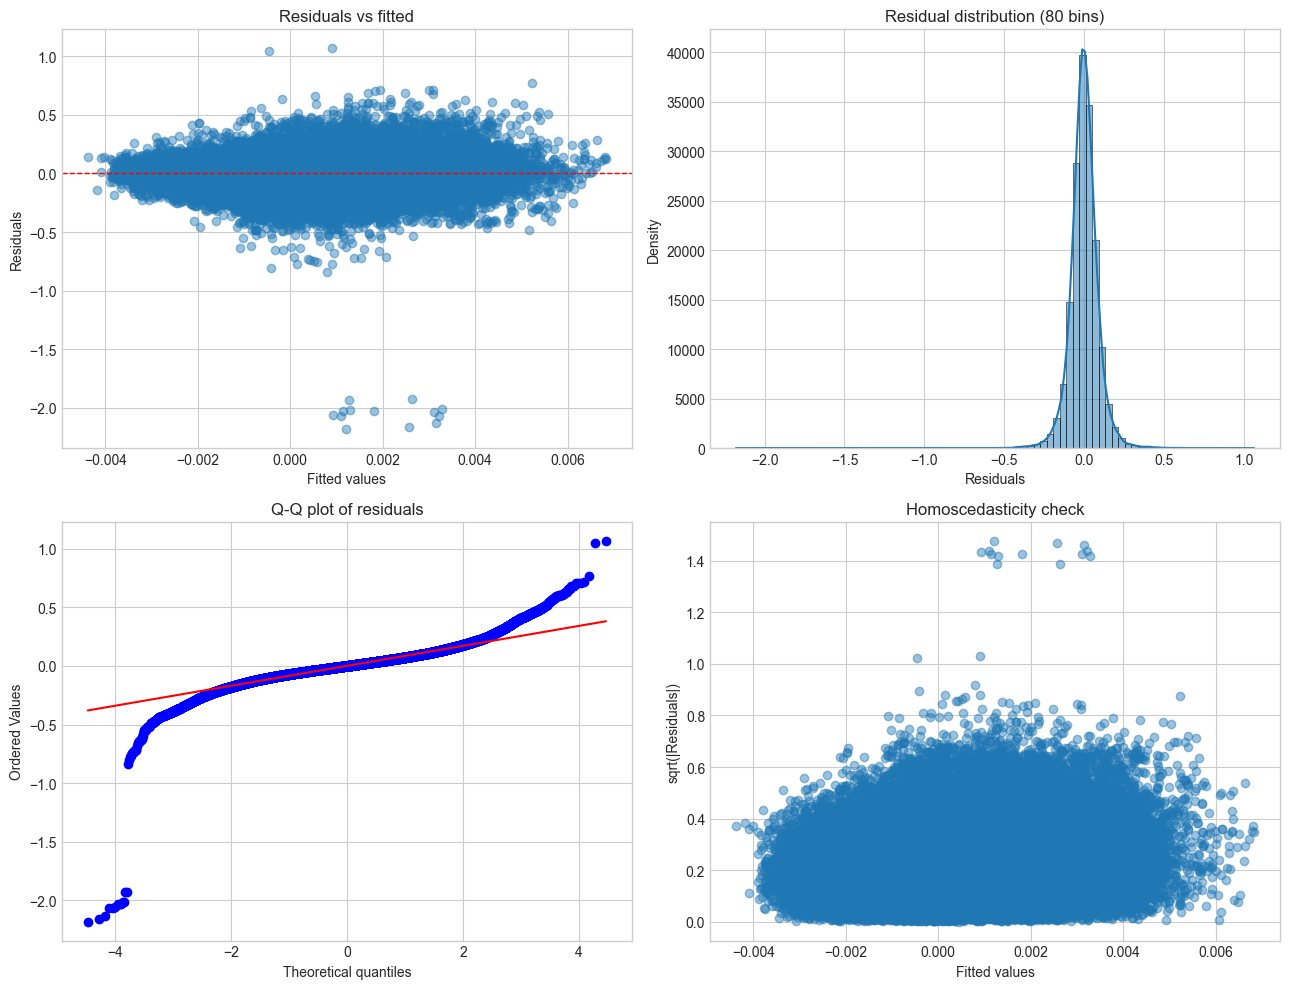

Linear regression assumption study
Rows used: 692378
Test-set R^2: 0.0018
Durbin-Watson statistic: 0.1061
Residual skewness: -0.9131
Residual kurtosis: 29.1220
Independence: residuals may show autocorrelation.


In [10]:
df = build_regression_frame()
study_linear_regression_assumptions(df)


In [11]:
#df